In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
import xarray as xr
import scipy as sp

import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _regionCCG(session,regs=None,when='sleep.*#0',bin=0.05,limits=(-0.5,0.5)):

    # load data
    R = fma.regions.regions(session,phases=when,states='sws',events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    n_units = np.array([len(R.units(r)) for r in regs])
    events = isau.loadHpcPfcEvents(session)

    spikes = []
    for i, r in enumerate(regs):
        s = R.spikes(r)
        s[:,1] = i
        spikes.append(s)
    spikes = np.concatenate(spikes)

    conditions = {'isa': R.eventIntervals('slownr'), 'nisa': R.eventIntervals([['sws','/slownr']])} # MAYBE add rem?
    lim_oscill = [[-1,1],[-1,1],[-3,3]]
    for i, e in enumerate(events):
        conditions[e] = events[e][:,None] + lim_oscill[i]

    ccg = []
    for condition in conditions.values():
        s = fma.general.restrict(spikes,condition)
        c, t = fma.analysis.CCG(s,bin,limits)
        c /= n_units[:,None,None] # convert to Hz / unit
        ccg.append(c)

    ccg = xr.DataArray(ccg,dims=['cond','reg0','reg1','t'],coords={'cond': list(conditions.keys()), 'reg0': regs, 'reg1': regs, 't': t, 'rat': int(R.rat)})

    return ccg

In [3]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][18]
print(session)
regs = ['hpc','nr','pfc']
ccg = _regionCCG(session,regs=regs,bin=0.005,limits=(-0.1,0.1))

/mnt/hubel-data-140/karadoc/Rat004_20240305/Rat004_20240305.xml


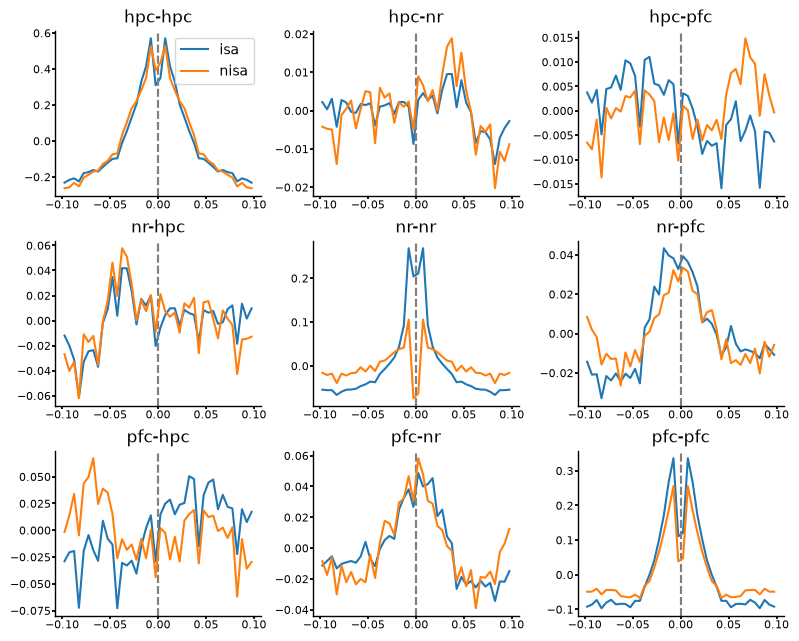

In [4]:
n_regs = len(regs)
conds = ['isa','nisa']
#conds = ccg.cond.values[2:]
#conds = ['isa','ripples']
fig, ax = fma.plotting.makeFigure(n=(n_regs,n_regs),size=(20,16))
for cond in conds:
    for i, r0 in enumerate(regs):
        for j, r1 in enumerate(regs):
            c = ccg.sel(cond=cond).sel(reg0=r0,reg1=r1)
            c -= c.mean(dim='t')
            ax[i,j].axvline(0,color='gray',ls='--')
            ax[i,j].plot(ccg.t,c,label=cond)
            ax[i,j].set(title=f'{r0}-{r1}')
ax[0,0].legend();

rnu batch

In [5]:
regs = ['hpc','nr','pfc']
ccg = fma.data.runBatch(batch_file,_regionCCG,kwargs={'regs': regs, 'bin': 0.01, 'limits': (-0.3,0.3)},parallel=True)
ccg_cat = xr.concat([d for d in ccg if d is not None],dim='rat',join='outer',coords='all') # (event, time, region)
ccg_avg = ccg_cat.groupby('rat').mean(skipna=True)


Starting Batch, 2026-08-17 11:10:25.889425 

Error in session /mnt/hubel-data-139/karadoc/Rat004_20240303/Rat004_20240303.xml (17)
zero-size array to reduction operation maximum which has no identity
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
list indices must be integers or slices, not tuple
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816

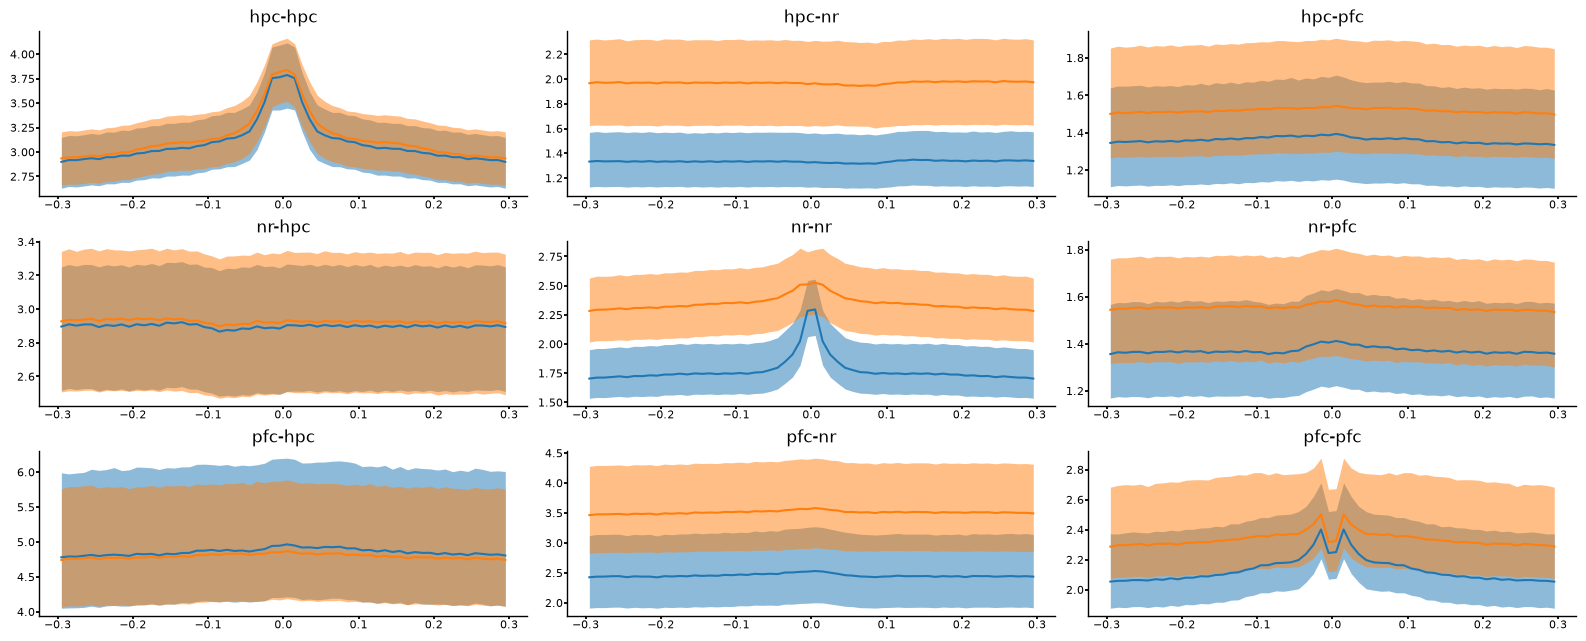

In [6]:
conditions = ['isa','nisa']
n_regs = len(regs)
fig, ax = fma.plotting.makeFigure(n=(n_regs,n_regs),size=(40,16))
for k, cond in enumerate(conditions):
    for i, r0 in enumerate(regs):
        for j, r1 in enumerate(regs):
            ax[i,j].set(title=f'{r0}-{r1}')

            c = ccg_cat.sel(cond=cond).sel(reg0=r0,reg1=r1).values
            fma.plotting.semPlot(ccg_cat.t,c,ax=ax[i,j])# ,zscore=1,sortby='peak-show')


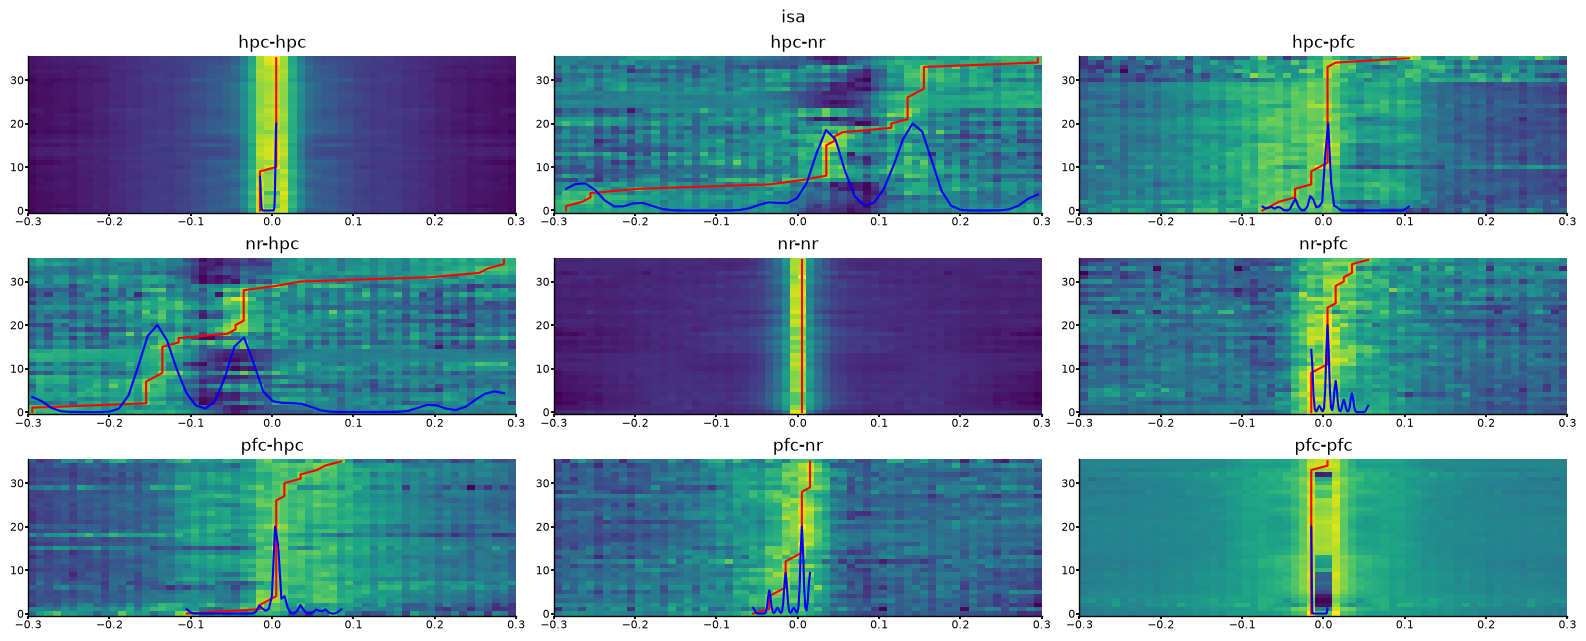

In [28]:
cond = ccg_cat.cond.values[0]
n_regs = len(regs)
fig, ax = fma.plotting.makeFigure(cond,n=(n_regs,n_regs),size=(40,16))
for i, r0 in enumerate(regs):
        for j, r1 in enumerate(regs):
            ax[i,j].set(title=f'{r0}-{r1}')

            c = ccg_cat.sel(cond=cond).sel(reg0=r0,reg1=r1).values
            fma.plotting.plotColorMap(c,x=ccg_cat.t,ax=ax[i,j],zscore=1,sortby='peak-show')

            peaks = ccg_cat.t.values[np.argmax(c,axis=1)]
            x, y = fma.analysis.PDF(peaks,bandwidth=0.1,norm='max')
            ax[i,j].plot(x,y*20,color='b')

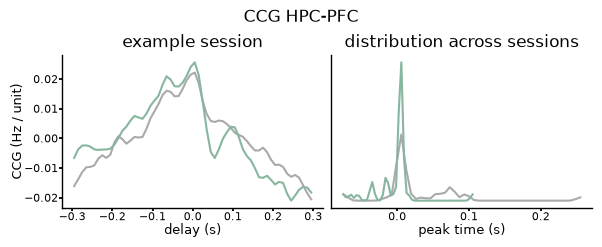

In [11]:
# peak HPC-NR bin 0.01 lim (-0.3,0.3)
ex = 9
conds = ['nisa','isa']
r0 = 'hpc'
r1 = 'pfc'
colors = ['shuffle','hpc']
fig, ax = fma.plotting.makeFigure(f'CCG {r0.upper()}-{r1.upper()}',n=(1,2),size=(15,6))
peaks = []
for i, cond in enumerate(conds):
    c = ccg_cat.sel(cond=cond).sel(reg0=r0,reg1=r1).values
    peaks.append(ccg_cat.t.values[np.argmax(c,axis=1)])
    m = sp.ndimage.gaussian_filter(c[ex] - c[ex].mean(axis=0),1)
    ax[0].plot(ccg_cat.t,m,color=isau.paperColors(colors[i]))
ax[0].set(xlabel='delay (s)',ylabel='CCG (Hz / unit)',title='example session')
#fma.plotting.boxPlot(peaks,color=isau.paperColors(colors),x=[1,1.2],label=['ISA','nISA'])
#ax[1].set(xlim=(0.8,1.4),ylabel='peak time (s)');
fma.plotting.plotPDF(tuple(peaks),bandwidth=0.1,color=isau.paperColors(colors),ax=ax[1])
ax[1].set(xlabel='peak time (s)',title='distribution across sessions');
#x, y = fma.analysis.PDF(peaks,bandwidth=0.1,norm='max')
#ax[i,j].plot(x,y*20,color='b')

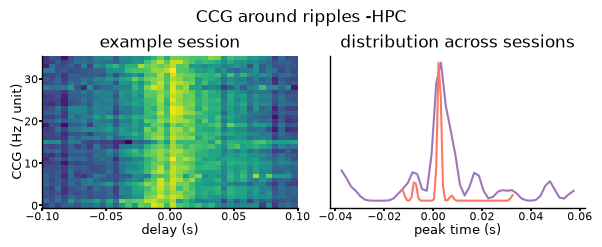

In [25]:
# peak HPC-NR bin 0.005 lim (-0.1,0.1)
ex = 9
conds = 'ripples'
reg0 = ['nr','pfc']
r1 = 'hpc'
colors = ['nr','pfc']
fig, ax = fma.plotting.makeFigure(f'CCG around ripples -{r1.upper()}',n=(1,2),size=(15,6))
peaks = []
for i, r0 in enumerate(reg0):
    c = ccg_cat.sel(cond=cond).sel(reg0=r0,reg1=r1).values
    peaks.append(ccg_cat.t.values[np.argmax(c,axis=1)])
    fma.plotting.plotColorMap(c,x=ccg_cat.t,ax=ax[0],zscore=1,sortby='peak')
ax[0].set(xlabel='delay (s)',ylabel='CCG (Hz / unit)',title='example session')
#fma.plotting.boxPlot(peaks,color=isau.paperColors(colors),x=[1,1.2],label=['ISA','nISA'])
#ax[1].set(xlim=(0.8,1.4),ylabel='peak time (s)');
fma.plotting.plotPDF(tuple(peaks),bandwidth=0.1,color=isau.paperColors(colors),ax=ax[1],norm='max')
ax[1].set(xlabel='peak time (s)',title='distribution across sessions');
#x, y = fma.analysis.PDF(peaks,bandwidth=0.1,norm='max')
#ax[i,j].plot(x,y*20,color='b')